In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [5]:
df = pd.read_csv("ANEMIA_DA.csv", sep = ";")
df['GRADO_SEVERIDAD'] = df['GRADO_SEVERIDAD'].str.upper()
df['ETNIA_AGRUPADA'] = df['ETNIA'].mask(df['ETNIA'].str.upper() != 'MESTIZO', 'INDIGENA')
altitud_media = {
    'PROVINCIA': [
        'MOYOBAMBA', 'BELLAVISTA', 'EL DORADO', 'HUALLAGA', 
        'LAMAS', 'MARISCAL CACERES', 'PICOTA', 'RIOJA', 
        'SAN MARTIN', 'TOCACHE'
    ],
    'ALTITUD_MSNM': [878, 285, 346, 303, 791, 282, 223, 841, 356, 502]
}
df_maestro_alt = pd.DataFrame(altitud_media)
df['PROVINCIA'] = df['PROVINCIA'].str.upper().str.strip()
df['PROVINCIA'] = df['PROVINCIA'].str.replace('Á', 'A').str.replace('É', 'E').str.replace('Í', 'I').str.replace('Ó', 'O').str.replace('Ú', 'U')
df = df.merge(df_maestro_alt, on='PROVINCIA', how='left')

def dias(row):
    edad = row['EDAD_REGISTRO']
    tipo = str(row['TIPO_EDAD']).upper().strip()
    
    if tipo == 'A':    # Años
        return edad
    elif tipo == 'M':  # Meses
        return edad * 30
    elif tipo == 'D':  # Días
        return edad
    else:
        return None    

df['EDAD_EN_DIAS'] = df.apply(dias, axis=1)
mapping = {
    'LEV': 0,
    'MOD': 1,
    'SEV': 1
}

df['TARGET_PRIORIDAD'] = df['GRADO_SEVERIDAD'].map(mapping)

In [8]:
# 1. Preparación inicial: Índice y Limpieza
# Establecemos PK_REGISTRO como índice para identificar filas sin usarlo como predictor
if 'PK_REGISTRO' in df.columns:
    df.set_index('PK_REGISTRO', inplace=True)

# 2. Definición de variables X e y
# Seleccionamos las columnas según tu requerimiento
X = df[['EDAD_EN_DIAS', 'ETNIA', 'DIAGNOSTICO', 'CANTIDAD', 'ALTITUD_MSNM']]
y = df['TARGET_PRIORIDAD']

# 3. Configuración de One-Hot Encoding (OHE)
# Usamos ColumnTransformer para procesar ETNIA y DIAGNOSTICO simultáneamente
categorical_features = ['ETNIA', 'DIAGNOSTICO']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Mantiene EDAD_EN_DIAS, CANTIDAD y ALTITUD_MSNM sin cambios
)

# 4. Transformación de los datos
# Nota: fit_transform convierte las categorías en columnas binarias (0 y 1)
X_encoded = preprocessor.fit_transform(X)

# Obtenemos los nombres de las nuevas columnas para reconstruir el DataFrame
nombres_columnas = preprocessor.get_feature_names_out()

# Reconstruimos el DataFrame manteniendo el índice original (PK_REGISTRO)
X_final = pd.DataFrame(X_encoded, columns=nombres_columnas, index=X.index)

# 5. División del Dataset (Train / Test Split)
# Usamos stratify=y para mantener la proporción de la variable objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X_final, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 6. Verificación de resultados
print("--- Resumen del Procesamiento ---")
print(f"Dimensiones finales de X: {X_final.shape}")
print(f"Registros para Entrenamiento: {X_train.shape[0]}")
print(f"Registros para Prueba: {X_test.shape[0]}")


--- Resumen del Procesamiento ---
Dimensiones finales de X: (59225, 13)
Registros para Entrenamiento: 47380
Registros para Prueba: 11845


--- Logit con Oversampling ---
F1-Score CV (Mean): 0.4311 (+/- 0.0027)
              precision    recall  f1-score   support

           0       0.79      0.70      0.75      9291
           1       0.24      0.33      0.28      2554

    accuracy                           0.62     11845
   macro avg       0.51      0.52      0.51     11845
weighted avg       0.67      0.62      0.64     11845

------------------------------
--- Logit con Undersampling ---
F1-Score CV (Mean): 0.4330 (+/- 0.0113)
              precision    recall  f1-score   support

           0       0.79      0.70      0.74      9291
           1       0.24      0.34      0.28      2554

    accuracy                           0.62     11845
   macro avg       0.51      0.52      0.51     11845
weighted avg       0.67      0.62      0.64     11845

------------------------------
--- XGBoost con Oversampling ---
F1-Score CV (Mean): 0.6152 (+/- 0.0088)
              precision    recall  f1-score   support

           0 

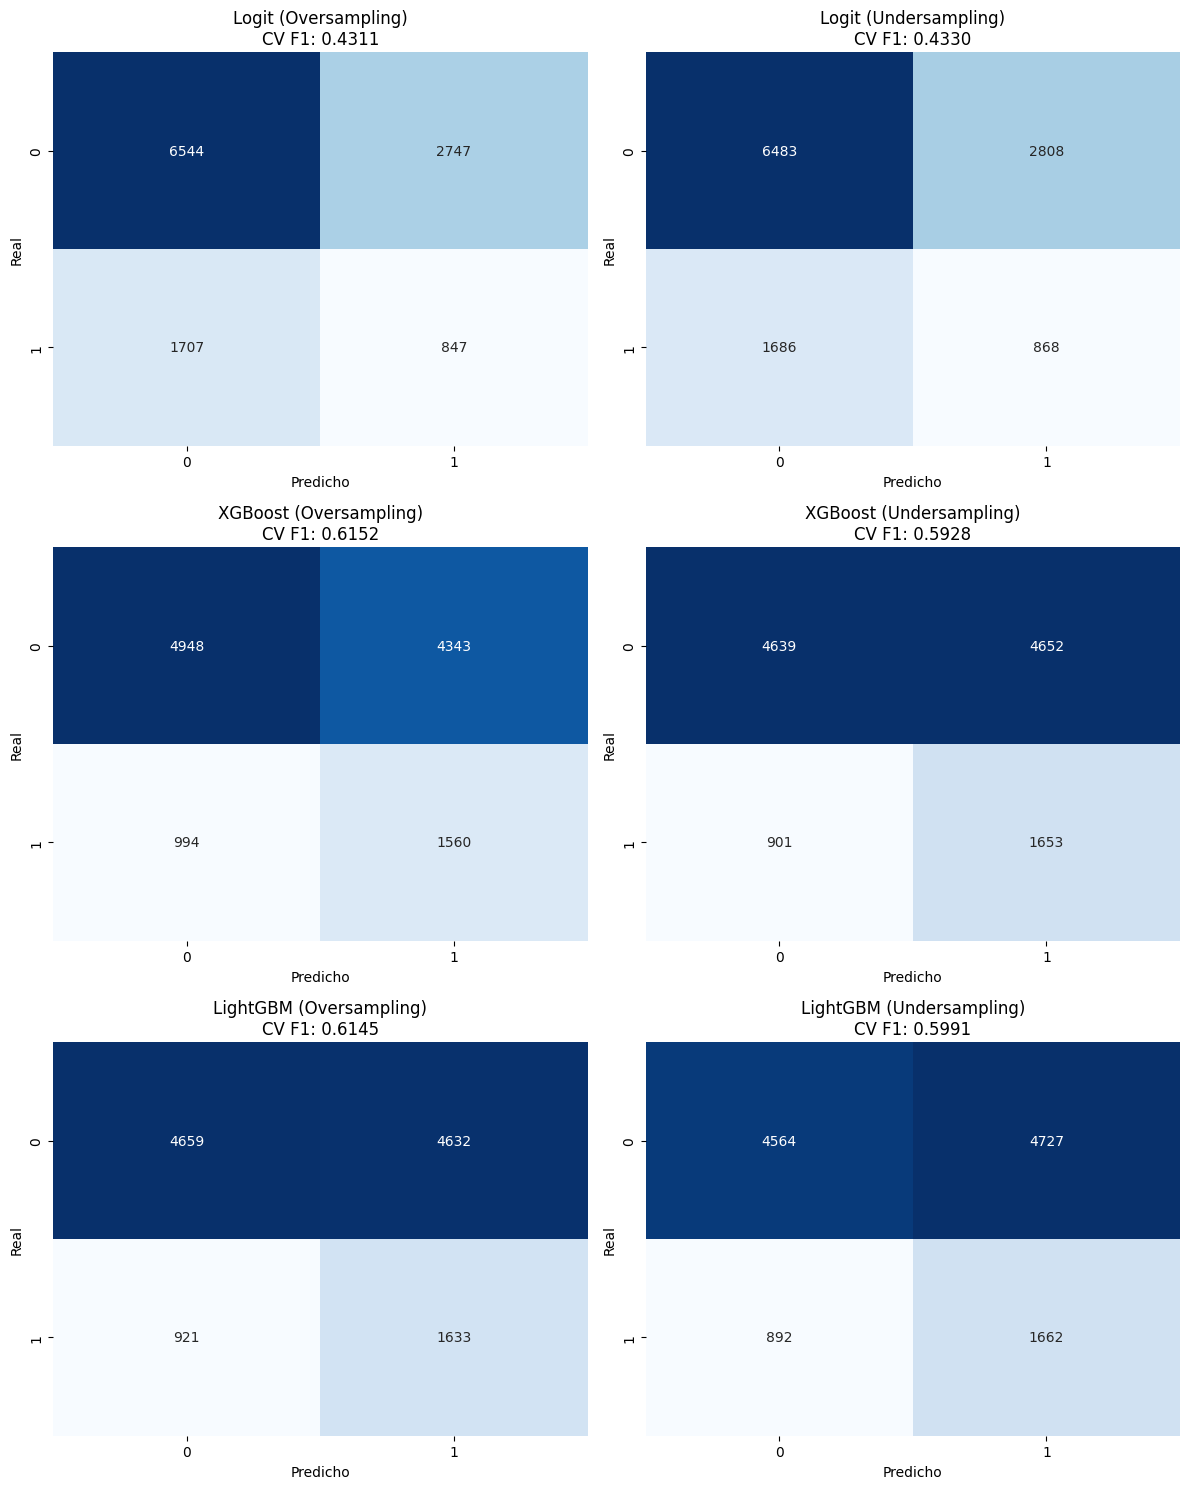

In [12]:

# 1. Definición de Técnicas de Remuestreo
over = SMOTE(random_state=42)
under = RandomUnderSampler(random_state=42)

estrategias = {
    'Oversampling': over.fit_resample(X_train, y_train),
    'Undersampling': under.fit_resample(X_train, y_train)
}

modelos = {
    'Logit': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Configuración de Validación Cruzada (5 Folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Bucle de Entrenamiento, Validación y Matriz de Confusión
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()
idx = 0

for mod_nombre, model in modelos.items():
    for est_nombre, (X_res, y_res) in estrategias.items():
        
        # Validación Cruzada sobre el set de entrenamiento remuestreado
        cv_scores = cross_val_score(model, X_res, y_res, cv=skf, scoring='f1')
        
        # Entrenamiento final para evaluar en Test
        model.fit(X_res, y_res)
        y_pred = model.predict(X_test)
        
        # Matriz de Confusión
        cm = confusion_matrix(y_test, y_pred)
        
        # Graficar Matriz
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues', cbar=False)
        axes[idx].set_title(f'{mod_nombre} ({est_nombre})\nCV F1: {cv_scores.mean():.4f}')
        axes[idx].set_xlabel('Predicho')
        axes[idx].set_ylabel('Real')
        
        print(f"--- {mod_nombre} con {est_nombre} ---")
        print(f"F1-Score CV (Mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        print(classification_report(y_test, y_pred))
        print("-" * 30)
        
        idx += 1

plt.tight_layout()
plt.show()